#### AI & ML Foundations Topics

- **Linear Algebra Basics**
  - Vectors
  - Dot product (intuition)

- **Statistics Fundamentals**
  - Mean
  - Variance
  - Standard deviation
  - Correlation

- **Probability Basics**
  - Normal distribution
  - Binomial distribution
  - Bayes’ theorem (intuition)
  
- **Derivatives Basics**
  - Derivatives Rules
    - Product rule
    - Quotient rule
    - chain rule
  - Multi variable function
    - partial derivatives
    - Gradient
    - Directional derivatives
  - Gradient Descent

In [1]:
# Vectors
# Dot product (intuition)
import matplotlib.pyplot as plt
import numpy as np
# Define two vectors
a = np.array([2, 3])
b = np.array([4, 1])

# Vector length (magnitude)
norm_a = np.linalg.norm(a) # linear  algebra norm(length) of a
norm_b = np.linalg.norm(b)
print("||a|| =", norm_a)
print("||b|| =", norm_b)

# Dot product
dot = np.dot(a, b)
print("Dot product a·b =", dot)

# Angle between vectors in degrees
theta = np.arccos(dot / (norm_a * norm_b))  # in radians
theta_deg = np.degrees(theta)
print("Angle between a and b (degrees) =", theta_deg)

# Projection of a onto b
proj = (dot / norm_b**2) * b  #
print("Projection of a onto b:", proj) 


# Compute angle between vectors in degrees
angle_rad = np.arccos(dot / (np.linalg.norm(a) * np.linalg.norm(b)))
angle_deg = np.degrees(angle_rad)
print(f"Angle between vectors = {angle_deg:.2f}°")

||a|| = 3.605551275463989
||b|| = 4.123105625617661
Dot product a·b = 11
Angle between a and b (degrees) = 42.27368900609373
Projection of a onto b: [2.58823529 0.64705882]
Angle between vectors = 42.27°


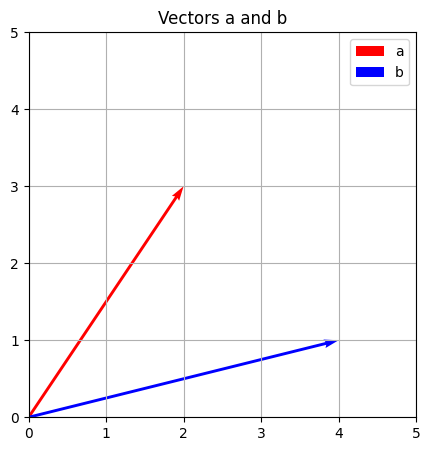

In [2]:
# plotting
plt.figure(figsize=(5,5))

# Plot vector a (red arrow) starting at origin (0,0)
# angles='xy', scale_units='xy', scale=1 ensures proper scaling
plt.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='r', label='a')

# Plot vector b (blue arrow) starting at origin (0,0)
plt.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='b', label='b')

# Set x and y axis limits so vectors fit nicely
plt.xlim(0,5)
plt.ylim(0,5)

# Add grid for easier visualization
plt.grid(True)

# Add legend to distinguish vectors
plt.legend() # it automatically  uses  label from quiver

# Add a title for context
plt.title('Vectors a and b')

# Display the plot
plt.show()

In [3]:
# Statistics Fundamentals

#     Mean
#     Variance
#     Standard deviation
#     Correlation


#dataset
data = np.array([2, 4, 6, 8, 10])
# Another dataset for correlation
data2 = np.array([1, 3, 5, 7, 9])

# 1. Mean: average value
mean = np.mean(data)
print("Mean:", mean)  # (2+4+6+8+10)/5 = 6

# 2. Variance: how spread out the data is
variance = np.var(data)
print("Variance:", variance)  # Average of squared differences from mean

# 3. Standard Deviation: typical distance from the mean
std_dev = np.std(data)
print("Standard Deviation:", std_dev)  # Square root of variance

# 4. Correlation: measures linear relationship between two datasets
correlation = np.corrcoef(data, data2)[0,1] 
# Extract correlation coefficient , here 0,1 is matrix indexing
print("Correlation between data and data2:", correlation)  # 1 = perfectly positively correlated

Mean: 6.0
Variance: 8.0
Standard Deviation: 2.8284271247461903
Correlation between data and data2: 0.9999999999999999


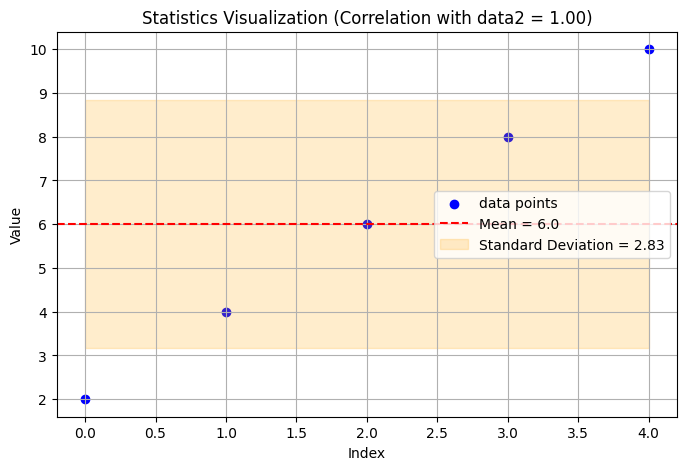

In [4]:
# Figure for plotting with size 8x5 inches
plt.figure(figsize=(8,5))

# Plot data points as blue dots
# range(len(data)) gives x-coordinates (0,1,2,...)
# data gives y-coordinates (values)
plt.scatter(range(len(data)), data, color='blue', label='data points')

# Plot a horizontal red dashed line for the mean
# y=mean → all points along y = mean
# linestyle='--' makes it dashed
plt.axhline(y=mean, color='red', linestyle='--', label=f'Mean = {mean}')

# Show standard deviation as an orange shaded area around the mean
# mean - std_dev → lower bound
# mean + std_dev → upper bound
# alpha=0.2 → makes the shading transparent
plt.fill_between(range(len(data)), mean - std_dev, mean + std_dev, color='orange', alpha=0.2, label=f'Standard Deviation = {std_dev:.2f}')

# Add title with correlation information
plt.title(f'Statistics Visualization (Correlation with data2 = {correlation:.2f})')

# Label axes
plt.xlabel('Index')
plt.ylabel('Value')

# Add legend to identify plotted elements
plt.legend()

# Add grid for easier visualization
plt.grid(True)

# Display the plot
plt.show()


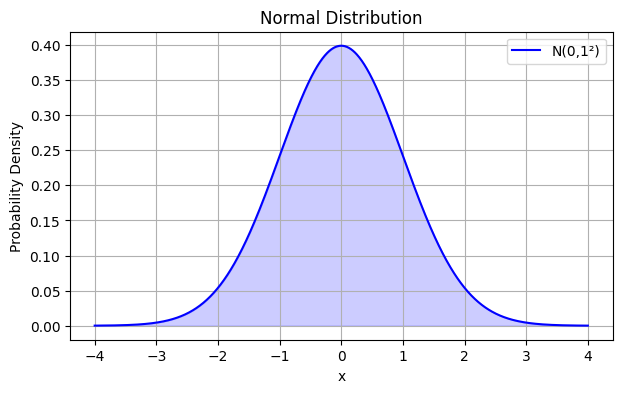

In [5]:
# Probability Basics

#     Normal distribution
from scipy.stats import norm # for advance mathematics
 
# Parameters
mu = 0      # mean
sigma = 1   # standard deviation

# Values
x = np.linspace(-4, 4, 1000) # (start, end , total points)
y = norm.pdf(x, mu, sigma)  # probability density function

# Plot
plt.figure(figsize=(7,4))
plt.plot(x, y, color='blue', label=f'N({mu},{sigma}²)')
plt.fill_between(x, 0, y, color='blue', alpha=0.2)
plt.title("Normal Distribution")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.show()

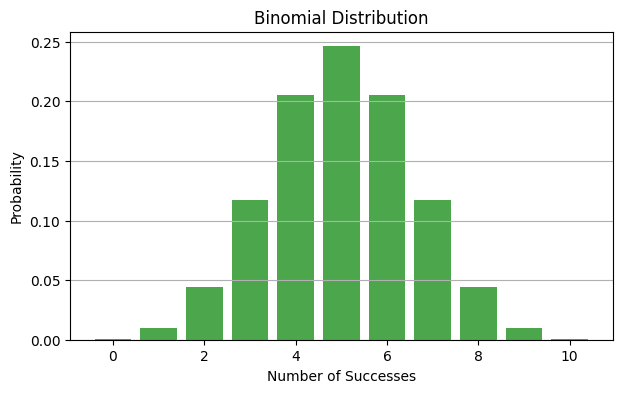

In [6]:
# Binomial Distribution

from scipy.stats import binom

# Parameters
n = 10    # number of trials
p = 0.5   # probability of success

# Possible outcomes
x = np.arange(0, n+1)
y = binom.pmf(x, n, p)  # probability mass function

# Plot
plt.figure(figsize=(7,4))
plt.bar(x, y, color='green', alpha=0.7)
plt.title("Binomial Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.grid(axis='y')
plt.show()

In [7]:
# Bayes Theorem
# Example: Disease test
# P(Disease) = 0.01, P(Test+|Disease) = 0.99, P(Test+|NoDisease) = 0.05

P_D = 0.01
P_notD = 1 - P_D
P_pos_given_D = 0.99
P_pos_given_notD = 0.05

# Bayes' Theorem: P(Disease|Test+)
P_D_given_pos = (P_pos_given_D * P_D) / (P_pos_given_D*P_D + P_pos_given_notD*P_notD)
print(f"Probability of disease given positive test: {P_D_given_pos:.3f}")

Probability of disease given positive test: 0.167


    Feature 1  Feature 2  Class
0    2.496714   1.861736      0
1    2.647689   3.523030      0
2    1.765847   1.765863      0
3    3.579213   2.767435      0
4    1.530526   2.542560      0
..        ...        ...    ...
95   3.553485   4.856399      1
96   4.214094   2.754261      1
97   4.173181   4.385317      1
98   3.116143   4.153725      1
99   4.058209   2.857030      1

[100 rows x 3 columns]

______________

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Accuracy: 0.92
Confusion Matrix:
 [[14  0]
 [ 2  9]]

______________



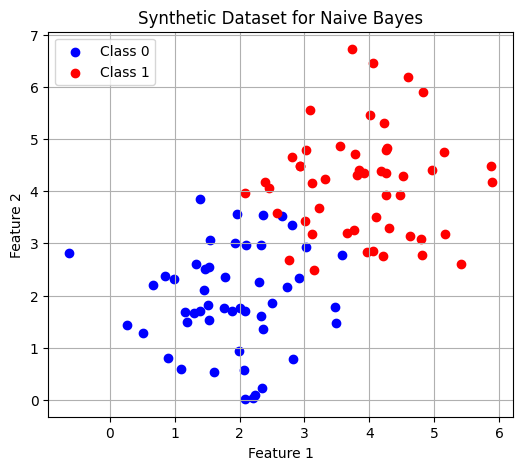

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd


np.random.seed(42)

# Class 0: centered at (2,2), with some spread
class0 = np.random.normal(loc=2, scale=1.0, size=(50,2)) 
# HERE LOC =MEAN, SCALE= Sd

# Class 1: centered at (4,4), with some spread (overlap with class 0)
class1 = np.random.normal(loc=4, scale=1.0, size=(50,2))

# Combine data
X = np.vstack((class0, class1))
y = np.array([0]*50 + [1]*50)

df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
df['Class'] = y

print(df)
print("\n______________\n")
# Split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(y)

# Train Gaussian Naive Bayes

model = GaussianNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("\n______________\n")
# Visualize dataset

plt.figure(figsize=(6,5))
# Plot points of Class 0
# X[y==0] → select rows where label y is 0
# [:,0] → first feature (x-axis)
# [:,1] → second feature (y-axis)
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='blue', label='Class 0')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='red', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Dataset for Naive Bayes')
plt.legend()
plt.grid(True)
plt.show()

[[0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 ...
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]]


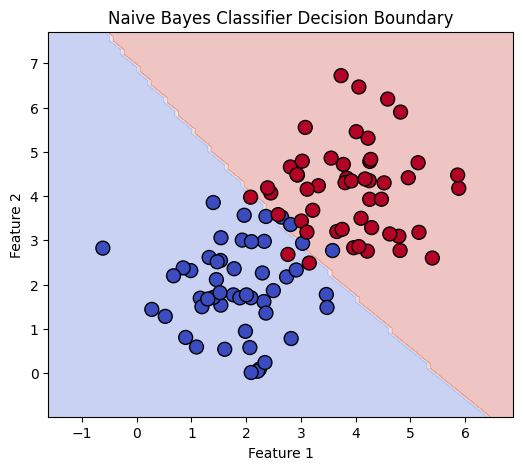

In [9]:
# Create a meshgrid for plotting decision boundary
# meshgrid creates a grid of coordinates over a 2D space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 # feature 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1 # feature 2

# Arrange the values
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# print(xx)
# print(yy)
# Predict class for each point in meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) #.ravel() flattens into 1D
Z = Z.reshape(xx.shape)
print(Z)
# Plot decision boundary
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap=plt.cm.coolwarm, s=100)
plt.title("Naive Bayes Classifier Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



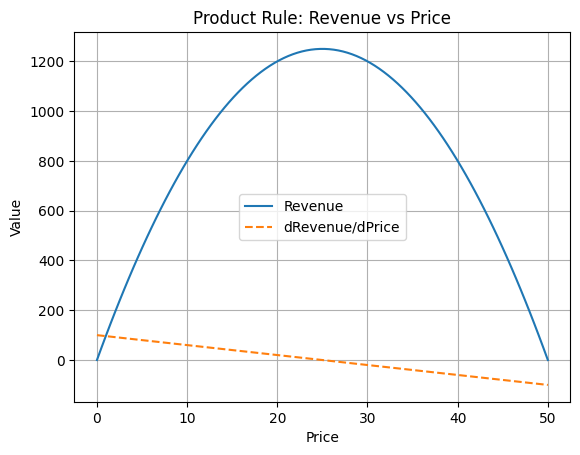

In [10]:
# Derivatives Basics

#     Derivatives Rules
#         Product rule
#         Quotient rule
#         chain rule
#     Multi variable function
#         partial derivatives
#         Gradient
#         Directional derivatives
#     Gradient Descent

# Product rule
import sympy as sp

# Define symbolic variable (price)
x = sp.symbols('x')

# Define functions
Price = x                      # price
Quantity = 100 - 2*x           # demand decreases with price
Revenue = Price * Quantity     # Revenue = Price * Quantity

# Product Rule: (f*g)' = f'*g + f*g'
dRevenue = sp.diff(Revenue, x)

# Convert symbolic expressions to numerical functions
Revenue_func = sp.lambdify(x, Revenue, 'numpy')
dRevenue_func = sp.lambdify(x, dRevenue, 'numpy')

# Create values for plotting
x_vals = np.linspace(0, 50, 100)

# Plot
plt.plot(x_vals, Revenue_func(x_vals), label='Revenue')
plt.plot(x_vals, dRevenue_func(x_vals), '--', label='dRevenue/dPrice')

plt.title("Product Rule: Revenue vs Price")
plt.xlabel("Price")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

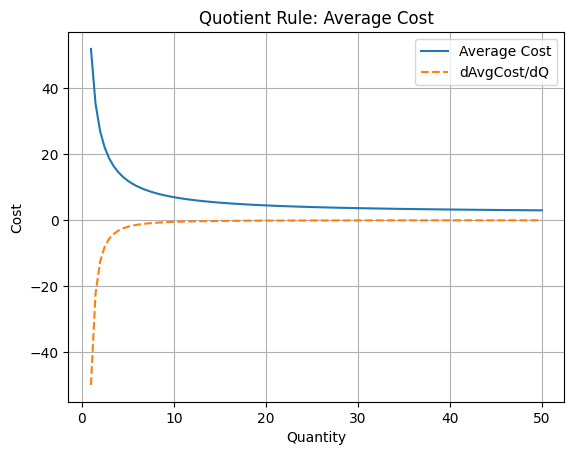

In [11]:
# Quotient rule
# Define symbolic variable (quantity)
Q = sp.symbols('Q')

# Define cost function
Total_cost = 50 + 2*Q          # fixed + variable cost
Avg_cost = Total_cost / Q      # average cost

# Quotient Rule: (f/g)' = (f'g - fg') / g^2
dAvg_cost = sp.diff(Avg_cost, Q)

# Convert to numerical functions
Avg_cost_func = sp.lambdify(Q, Avg_cost, 'numpy')
dAvg_cost_func = sp.lambdify(Q, dAvg_cost, 'numpy')

# Values for plotting
Q_vals = np.linspace(1, 50, 100)  # avoid division by 0

# Plot
plt.plot(Q_vals, Avg_cost_func(Q_vals), label='Average Cost')
plt.plot(Q_vals, dAvg_cost_func(Q_vals), '--', label='dAvgCost/dQ')

plt.title("Quotient Rule: Average Cost")
plt.xlabel("Quantity")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()

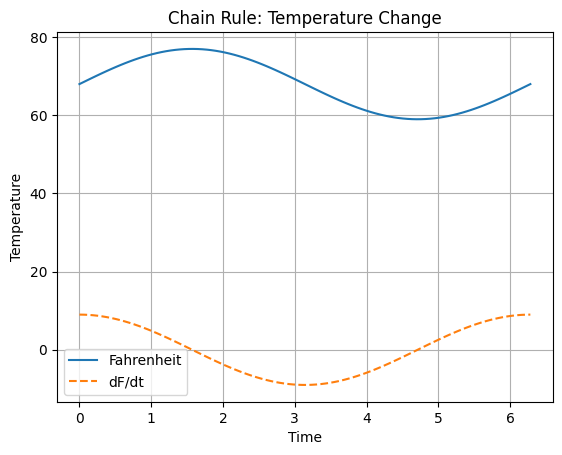

In [12]:
#  chain rule
# Define time variable
t = sp.symbols('t')

# Temperature in Celsius (changes over time)
C = 20 + 5*sp.sin(t)

# Convert to Fahrenheit
F = 9/5*C + 32

# Chain Rule: dF/dt = dF/dC * dC/dt
dF_dt = sp.diff(F, t)

# Convert to numerical functions
F_func = sp.lambdify(t, F, 'numpy')
dF_dt_func = sp.lambdify(t, dF_dt, 'numpy')

# Values for plotting
t_vals = np.linspace(0, 2*np.pi, 100)

# Plot
plt.plot(t_vals, F_func(t_vals), label='Fahrenheit')
plt.plot(t_vals, dF_dt_func(t_vals), '--', label='dF/dt')

plt.title("Chain Rule: Temperature Change")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
plt.show()

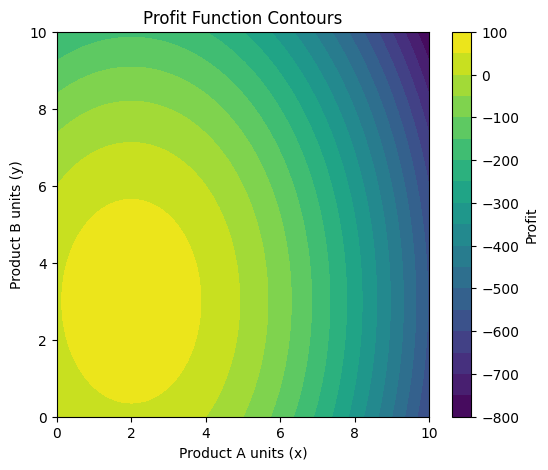

In [13]:
# partial derivatives

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define symbolic variables
x, y = sp.symbols('x y')  

# Profit function:
# Revenue = 40x + 30y
# Cost = 10x^2 + 5y^2
# Profit = Revenue - Cost
Profit = (40*x + 30*y) - (10*x**2 + 5*y**2)

# Partial derivatives:
# ∂Profit/∂x → change in profit when x changes (y fixed)
dProfit_dx = sp.diff(Profit, x)

# ∂Profit/∂y → change in profit when y changes (x fixed)
dProfit_dy = sp.diff(Profit, y)

# Create numerical values for plotting
x_vals = np.linspace(0, 10, 100)   # values for x (Product A)
y_vals = np.linspace(0, 10, 100)   # values for y (Product B)

# Create grid of (x, y) points
# This allows us to evaluate function at many points
X, Y = np.meshgrid(x_vals, y_vals)

# Convert symbolic function → numerical function
# So we can compute values for arrays
Profit_func = sp.lambdify((x, y), Profit, 'numpy')

# Compute profit values at each (x, y) point
Z = Profit_func(X, Y)

# Plot contour (2D "top view" of 3D surface)
plt.figure(figsize=(6,5))

# contourf → filled contour plot
# Each color represents a profit level
cp = plt.contourf(X, Y, Z, cmap='viridis', levels=20)

# Add color bar to show profit scale
plt.colorbar(cp, label='Profit')

# Titles and labels
plt.title('Profit Function Contours')
plt.xlabel('Product A units (x)')
plt.ylabel('Product B units (y)')

# Show plot
plt.show()

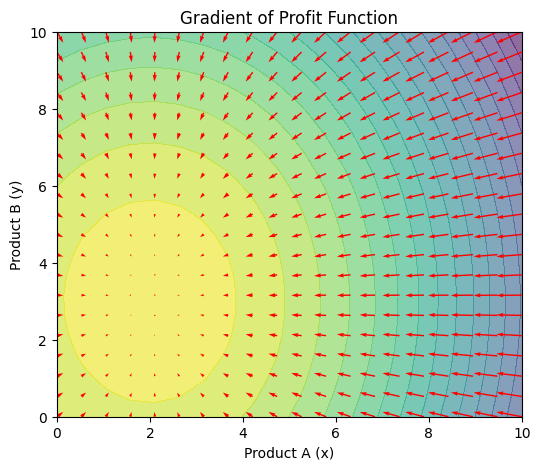

In [14]:
#Gradient

# Gradient: ∇Profit = [∂Profit/∂x, ∂Profit/∂y]
# This gives direction of steepest increase in profit
grad_Profit = [dProfit_dx, dProfit_dy]

# Convert symbolic gradient → numerical function
# So we can compute gradient values at many points
grad_func = sp.lambdify((x, y), grad_Profit, 'numpy')

# Create grid of points (x, y)
# Fewer points (20x20) so arrows are not too crowded
X, Y = np.meshgrid(np.linspace(0,10,20), np.linspace(0,10,20))

# Compute gradient at each grid point
# U = ∂Profit/∂x (x-direction change)
# V = ∂Profit/∂y (y-direction change)
U, V = grad_func(X, Y)

# Create plot
plt.figure(figsize=(6,5))

# Plot contour (profit levels as background)
# This shows "height" (profit) as colors
plt.contourf(X, Y, Profit_func(X, Y), cmap='viridis', levels=20, alpha=0.6)

# Plot gradient vectors (arrows)
# Each arrow shows direction of steepest increase at that point
plt.quiver(X, Y, U, V, color='red')

# Labels and title
plt.title('Gradient of Profit Function')
plt.xlabel('Product A (x)')
plt.ylabel('Product B (y)')

# Show plot
plt.show()

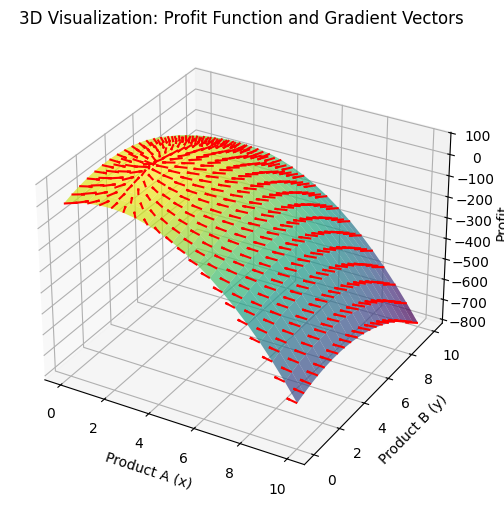

In [15]:
# 3D visualization of Gradent
from mpl_toolkits.mplot3d import Axes3D # MATPLOTLIB ko tool kit ho
import matplotlib.pyplot as plt 
import numpy as np

# Create a grid of points for x and y
# Using fewer points so the plot remains readable
x_vals = np.linspace(0, 10, 20)
y_vals = np.linspace(0, 10, 20)
X, Y = np.meshgrid(x_vals, y_vals)

# Compute the profit value at each point
Z = Profit_func(X, Y)  # Z = Profit(x, y)

# Compute gradient vectors (partial derivatives) at each grid point
U, V = grad_func(X, Y)  # U = ∂Profit/∂x, V = ∂Profit/∂y
W = np.zeros_like(U)     # Z-direction for arrows = 0 (arrows lie on surface)

# Create a 3D figure
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D surface of the profit function
# Color map shows height (profit), alpha controls transparency
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)

# Plot gradient vectors as arrows on the surface
# U, V = horizontal components, W=0 vertical component
# length=0.5 scales arrows, normalize=True ensures consistent arrow length
ax.quiver(X, Y, Z, U, V, W, color='red', length=0.5, normalize=True)

# Set axis labels
ax.set_xlabel('Product A (x)')
ax.set_ylabel('Product B (y)')
ax.set_zlabel('Profit')

# Set title
ax.set_title('3D Visualization: Profit Function and Gradient Vectors')

# Show the plot
plt.show()

Directional derivative at (5,2) in direction u: -28.0


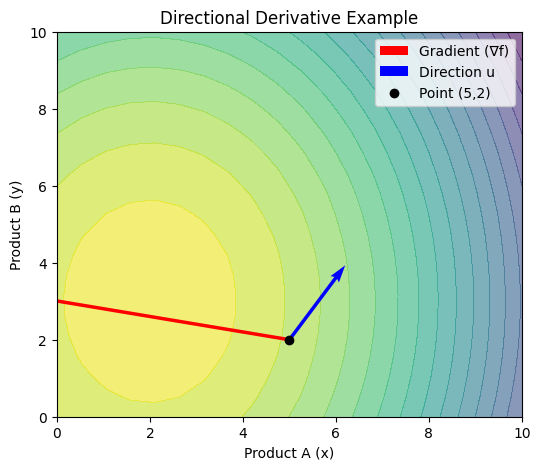

In [16]:
# Directional derivatives

# Directional derivative formula:
# D_u f = ∇f ⋅ u  (dot product of gradient and direction vector)

import numpy as np

# Define direction vector u
u = np.array([3, 4])

# Normalize the vector → convert to unit vector
# This ensures we measure rate of change per unit step
u = u / np.linalg.norm(u)

# Compute gradient at a specific point (5,2)
# grad_func gives [∂f/∂x, ∂f/∂y]
grad_at_point = np.array(grad_func(5, 2), dtype=float)

# Compute directional derivative using dot product
# Measures rate of change of function in direction u
dir_deriv = np.dot(grad_at_point, u)

# Print result
print("Directional derivative at (5,2) in direction u:", dir_deriv)


# ---------------- VISUALIZATION ----------------

plt.figure(figsize=(6,5))

# Plot contour of profit function (background)
# Shows profit levels as colors
plt.contourf(X, Y, Profit_func(X, Y), cmap='viridis', levels=20, alpha=0.6)

# Plot gradient vector at point (5,2)
# Red arrow = direction of steepest increase
plt.quiver(5, 2, grad_at_point[0], grad_at_point[1],
           color='red', scale=5, label='Gradient (∇f)')

# Plot direction vector u at same point
# Blue arrow = chosen direction
plt.quiver(5, 2, u[0], u[1],
           color='blue', scale=5, label='Direction u')

# Mark the point (5,2)
plt.scatter(5, 2, color='black', label='Point (5,2)')

# Labels and title
plt.title('Directional Derivative Example')
plt.xlabel('Product A (x)')
plt.ylabel('Product B (y)')

# Show legend
plt.legend()

# Show plot
plt.show()

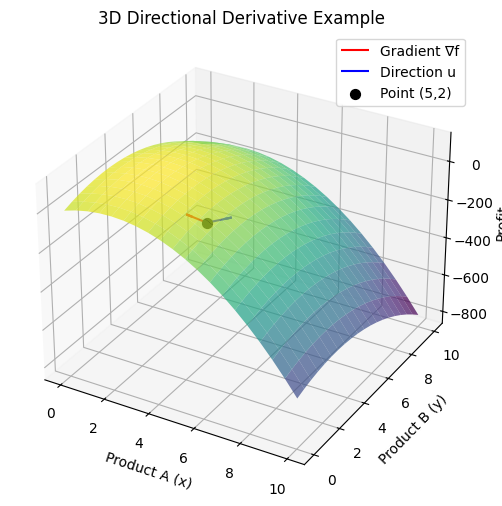

In [21]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Create a finer grid for smooth 3D surface
x_vals = np.linspace(0, 10, 20)
y_vals = np.linspace(0, 10, 20)
X, Y = np.meshgrid(x_vals, y_vals)
Z = Profit_func(X, Y)  # Profit values

# Gradient at point (5,2)
grad_at_point = np.array(grad_func(5, 2), dtype=float)

# Direction vector u (unit vector)
u = np.array([3, 4])
u = u / np.linalg.norm(u)

# ---------------- 3D Plot ----------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot profit surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)

# Plot gradient vector at (5,2) in 3D
# X, Y, Z = starting point, U, V, W = vector components
ax.quiver(5, 2, Profit_func(5,2),      # starting point
          grad_at_point[0], grad_at_point[1], 0,  # vector components (horizontal)
          color='red', length=1, normalize=True, label='Gradient ∇f')

# Plot direction vector u at same point
ax.quiver(5, 2, Profit_func(5,2),      # starting point
          u[0], u[1], 0,                # vector components
          color='blue', length=1, normalize=True, label='Direction u')

# Mark the point (5,2) on the surface
ax.scatter(5, 2, Profit_func(5,2), color='black', s=50, label='Point (5,2)')

# Labels and title
ax.set_xlabel('Product A (x)')
ax.set_ylabel('Product B (y)')
ax.set_zlabel('Profit')
ax.set_title('3D Directional Derivative Example')

# Show legend
ax.legend()

plt.show()

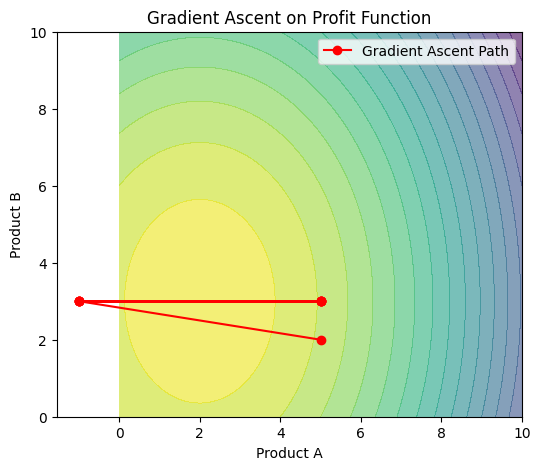

In [17]:
# Gradiant Ascent
# Initial point to start gradient ascent
x_val, y_val = 5.0, 2.0

# Learning rate controls the size of each step taken along the gradient
learning_rate = 0.1

# Lists to store the sequence of x and y values visited during the ascent
path_x, path_y = [x_val], [y_val]

# Perform 10 iterations of gradient ascent to maximize the profit function
for i in range(10):
    # Calculate the gradient (partial derivatives) at the current point (x_val, y_val)
    grad_at_point = np.array(grad_func(x_val, y_val), dtype=float)
    
    # Update the current point by moving in the direction of the gradient
    # This moves "uphill" towards higher profit values
    x_val += learning_rate * grad_at_point[0]
    y_val += learning_rate * grad_at_point[1]
    
    # Append the new point to the path lists for visualization later
    path_x.append(x_val)
    path_y.append(y_val)

# Create 2D grid for contour plot (fix issue here)
x_vals = np.linspace(0, 10, 100)
y_vals = np.linspace(0, 10, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

# Calculate profit function values on the grid
Z = Profit_func(X_grid, Y_grid)

# Visualize the profit function contours and the path taken by gradient ascent
plt.figure(figsize=(6,5))

# Use meshgrid arrays X_grid, Y_grid and Z for contour plot
plt.contourf(X_grid, Y_grid, Z, cmap='viridis', levels=20, alpha=0.6)

# Plot the path taken by the gradient ascent using red dots connected by lines
plt.plot(path_x, path_y, color='red', marker='o', label='Gradient Ascent Path')

# Add titles and labels for clarity
plt.title('Gradient Ascent on Profit Function')
plt.xlabel('Product A')
plt.ylabel('Product B')
plt.legend()
plt.show()

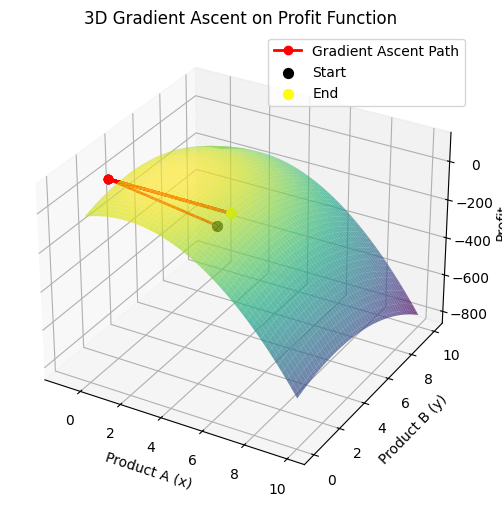

In [22]:
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting
import matplotlib.pyplot as plt
import numpy as np

# ----------------- Prepare grid for surface -----------------
x_vals = np.linspace(0, 10, 100)
y_vals = np.linspace(0, 10, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
Z = Profit_func(X_grid, Y_grid)  # Compute profit values on grid

# ----------------- Gradient ascent path -----------------
x_val, y_val = 5.0, 2.0  # Starting point
learning_rate = 0.1
path_x, path_y = [x_val], [y_val]
path_z = [Profit_func(x_val, y_val)]  # Store profit values along the path

for i in range(10):
    grad_at_point = np.array(grad_func(x_val, y_val), dtype=float)
    x_val += learning_rate * grad_at_point[0]
    y_val += learning_rate * grad_at_point[1]
    path_x.append(x_val)
    path_y.append(y_val)
    path_z.append(Profit_func(x_val, y_val))

# ----------------- 3D Visualization -----------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot profit surface
ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.7)

# Plot gradient ascent path
ax.plot(path_x, path_y, path_z, color='red', marker='o', label='Gradient Ascent Path', linewidth=2)

# Starting and ending points
ax.scatter(path_x[0], path_y[0], path_z[0], color='black', s=50, label='Start')
ax.scatter(path_x[-1], path_y[-1], path_z[-1], color='yellow', s=50, label='End')

# Labels and title
ax.set_xlabel('Product A (x)')
ax.set_ylabel('Product B (y)')
ax.set_zlabel('Profit')
ax.set_title('3D Gradient Ascent on Profit Function')

# Legend
ax.legend()
plt.show()

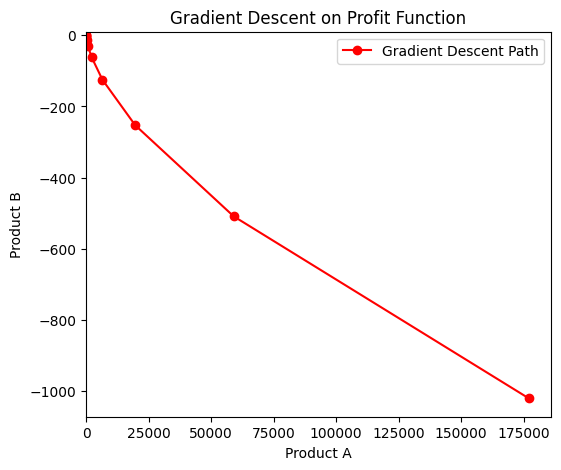

In [18]:
# Initial point to start gradient descent
x_val, y_val = 5.0, 2.0

# Learning rate controls the step size
learning_rate = 0.1

# Lists to store the path
path_x, path_y = [x_val], [y_val]

# Perform 10 iterations of gradient descent to minimize the profit function
for i in range(10):
    # Compute gradient at current point
    grad_at_point = np.array(grad_func(x_val, y_val), dtype=float)
    
    # Update rule for gradient descent:
    # Move in the negative gradient direction
    x_val -= learning_rate * grad_at_point[0]
    y_val -= learning_rate * grad_at_point[1]
    
    # Store updated points for visualization
    path_x.append(x_val)
    path_y.append(y_val)

# Create meshgrid for contour plot
x_vals = np.linspace(0, 10, 100)
y_vals = np.linspace(0, 10, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

# Compute profit function values for the grid
Z = Profit_func(X_grid, Y_grid)

# Plot the contour and gradient descent path
plt.figure(figsize=(6,5))
plt.contourf(X_grid, Y_grid, Z, cmap='viridis', levels=20, alpha=0.6)

# Plot the path of points visited by gradient descent
plt.plot(path_x, path_y, color='red', marker='o', label='Gradient Descent Path')

# Add titles and labels
plt.title('Gradient Descent on Profit Function')
plt.xlabel('Product A')
plt.ylabel('Product B')
plt.legend()
plt.show()

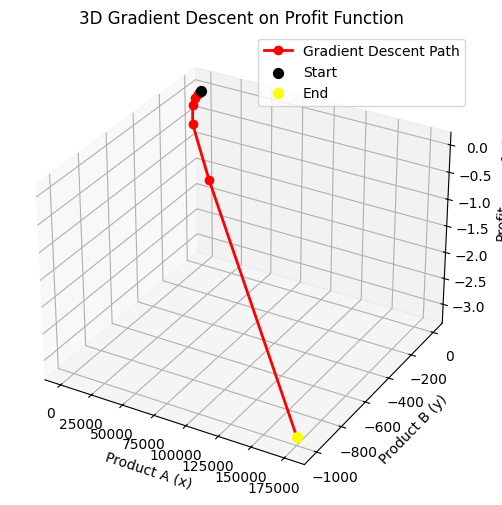

In [23]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# ----------------- Prepare grid for surface -----------------
x_vals = np.linspace(0, 10, 100)
y_vals = np.linspace(0, 10, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
Z = Profit_func(X_grid, Y_grid)  # Compute profit values on grid

# ----------------- Gradient descent path -----------------
x_val, y_val = 5.0, 2.0  # Starting point
learning_rate = 0.1
path_x, path_y = [x_val], [y_val]
path_z = [Profit_func(x_val, y_val)]  # Store profit values along the path

for i in range(10):
    grad_at_point = np.array(grad_func(x_val, y_val), dtype=float)
    
    # Move in negative gradient direction (downhill)
    x_val -= learning_rate * grad_at_point[0]
    y_val -= learning_rate * grad_at_point[1]
    
    path_x.append(x_val)
    path_y.append(y_val)
    path_z.append(Profit_func(x_val, y_val))

# ----------------- 3D Visualization -----------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot profit surface
ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.7)

# Plot gradient descent path (red line)
ax.plot(path_x, path_y, path_z, color='red', marker='o', label='Gradient Descent Path', linewidth=2)

# Starting and ending points
ax.scatter(path_x[0], path_y[0], path_z[0], color='black', s=50, label='Start')
ax.scatter(path_x[-1], path_y[-1], path_z[-1], color='yellow', s=50, label='End')

# Labels and title
ax.set_xlabel('Product A (x)')
ax.set_ylabel('Product B (y)')
ax.set_zlabel('Profit')
ax.set_title('3D Gradient Descent on Profit Function')

# Legend
ax.legend()
plt.show()

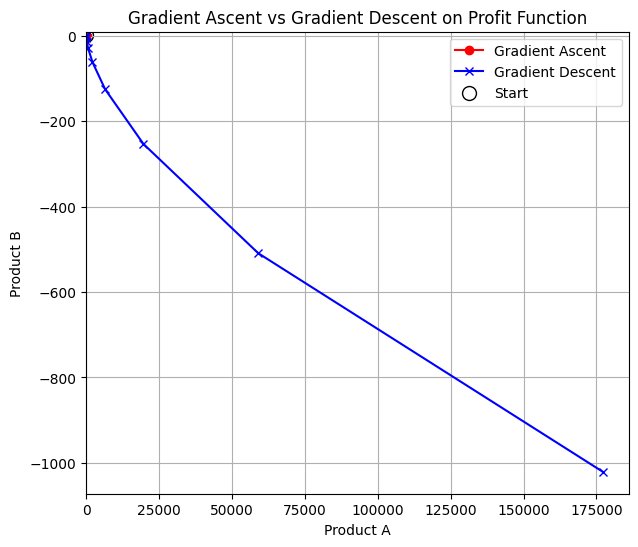

In [19]:
# Starting point
x_start, y_start = 5.0, 2.0
learning_rate = 0.1
steps = 10

# --- Gradient Ascent ---
x_val, y_val = x_start, y_start
path_ascent_x, path_ascent_y = [x_val], [y_val]

for i in range(steps):
    grad_at_point = np.array(grad_func(x_val, y_val), dtype=float)
    x_val += learning_rate * grad_at_point[0]  # move uphill
    y_val += learning_rate * grad_at_point[1]
    path_ascent_x.append(x_val)
    path_ascent_y.append(y_val)

# --- Gradient Descent ---
x_val, y_val = x_start, y_start
path_descent_x, path_descent_y = [x_val], [y_val]

for i in range(steps):
    grad_at_point = np.array(grad_func(x_val, y_val), dtype=float)
    x_val -= learning_rate * grad_at_point[0]  # move downhill
    y_val -= learning_rate * grad_at_point[1]
    path_descent_x.append(x_val)
    path_descent_y.append(y_val)

# --- Contour Plot ---
x_vals = np.linspace(0, 10, 100)
y_vals = np.linspace(0, 10, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
Z = Profit_func(X_grid, Y_grid)

plt.figure(figsize=(7,6))
plt.contourf(X_grid, Y_grid, Z, cmap='viridis', levels=20, alpha=0.6)

# Plot ascent path (red)
plt.plot(path_ascent_x, path_ascent_y, color='red', marker='o', label='Gradient Ascent')

# Plot descent path (blue)
plt.plot(path_descent_x, path_descent_y, color='blue', marker='x', label='Gradient Descent')

# Mark starting point
plt.scatter(x_start, y_start, color='white', edgecolor='black', s=100, label='Start')

plt.title('Gradient Ascent vs Gradient Descent on Profit Function')
plt.xlabel('Product A')
plt.ylabel('Product B')
plt.legend()
plt.grid(True)
plt.show()

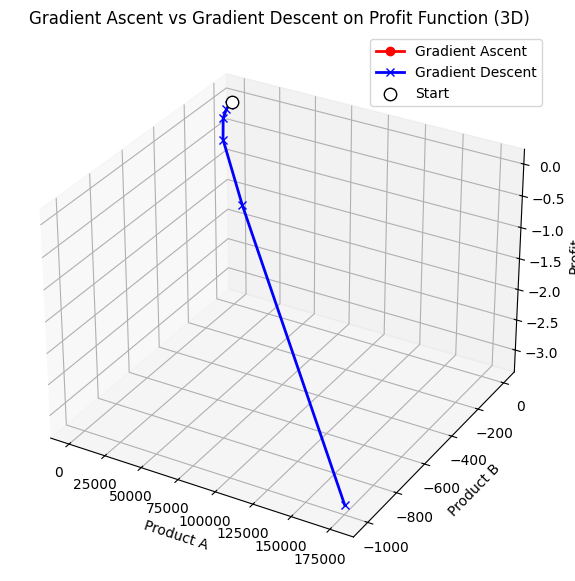

In [24]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# --- Gradient Ascent and Descent Paths ---
x_start, y_start = 5.0, 2.0
learning_rate = 0.1
steps = 10

# Gradient Ascent
x_val, y_val = x_start, y_start
path_ascent_x, path_ascent_y, path_ascent_z = [x_val], [y_val], [Profit_func(x_val, y_val)]
for i in range(steps):
    grad_at_point = np.array(grad_func(x_val, y_val), dtype=float)
    x_val += learning_rate * grad_at_point[0]  # move uphill
    y_val += learning_rate * grad_at_point[1]
    path_ascent_x.append(x_val)
    path_ascent_y.append(y_val)
    path_ascent_z.append(Profit_func(x_val, y_val))

# Gradient Descent
x_val, y_val = x_start, y_start
path_descent_x, path_descent_y, path_descent_z = [x_val], [y_val], [Profit_func(x_val, y_val)]
for i in range(steps):
    grad_at_point = np.array(grad_func(x_val, y_val), dtype=float)
    x_val -= learning_rate * grad_at_point[0]  # move downhill
    y_val -= learning_r    y_val -= learning_rate * grad_at_point[1]
    path_descent_x.append(x_val)
    path_descent_y.append(y_val)
    path_descent_z.append(Profit_func(x_val, y_val))

# --- Create 3D grid for surface ---
x_vals = np.linspace(0, 10, 100)
ate * grad_at_point[1]
    path_descent_x.append(x_val)
    path_descent_y.append(y_val)
    path_descent_z.append(Profit_func(x_val, y_val))

# --- Create 3D grid for surface ---
x_vals = np.linspace(0, 10, 100)
y_vals = np.linspace(0, 10, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
Z = Profit_func(X_grid, Y_grid)

# --- 3D Plot ---
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Surface of the profit function
ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.7)

# Gradient ascent path (red, uphill)
ax.plot(path_ascent_x, path_ascent_y, path_ascent_z, color='red', marker='o', linewidth=2, label='Gradient Ascent')

# Gradient descent path (blue, downhill)
ax.plot(path_descent_x, path_descent_y, path_descent_z, color='blue', marker='x', linewidth=2, label='Gradient Descent')

# Starting point marker
ax.scatter(x_start, y_start, Profit_func(x_start, y_start), color='white', edgecolor='black', s=80, label='Start')

# Labels and title
ax.set_xlabel('Product A')
ax.set_ylabel('Product B')
ax.set_zlabel('Profit')
ax.set_title('Gradient Ascent vs Gradient Descent on Profit Function (3D)')

# Legend
ax.legend()
plt.show()    y_val -= learning_rate * grad_at_point[1]
    path_descent_x.append(x_val)
    path_descent_y.append(y_val)
    path_descent_z.append(Profit_func(x_val, y_val))

# --- Create 3D grid for surface ---
x_vals = np.linspace(0, 10, 100)
